# Distributed Machine Learning & Parallel Computing
Hooman Sabzi

<img src="Dask-Logo-300x300-1.png" width="100" />

## Scalable Clustering with Dask: Implementing K-Means|| (Scalable K-Means++)
---

### Imports & Cluster Management

In [1]:
import gc
import time
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

import dask
import dask.bag as db
import dask.array as da

from dask.distributed import Client, SSHCluster, get_client, wait
from dask_ml.datasets import make_blobs
from dask_ml.preprocessing import StandardScaler
from dask_ml.cluster import KMeans as DaskKMeans
from sklearn.cluster import KMeans as LocalKMeans
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.datasets import fetch_rcv1, fetch_kddcup99

In [2]:
def start_cluster():
    """Starts a fresh SSH Cluster and returns the Client."""
    print("STARTING CLUSTER ...")
    
    host_list = [
        "10.67.22.10",   # Scheduler
        "10.67.22.225",  # Worker 1
        "10.67.22.53",   # Worker 2
        "10.67.22.162",  # Worker 3
        "10.67.22.171"   # Worker 4
    ]
    
    cluster = SSHCluster(
        host_list,
        connect_options={"known_hosts": None, "username": "ubuntu"},
        scheduler_options={"port": 8786, "dashboard_address": ":8787"}
    )
    client = Client(cluster)
    
    print(f"CLUSTER READY: {client.dashboard_link}")
    return client, cluster

def stop_cluster(client, cluster):
    """Cleanly shuts down the cluster."""
    print("SHUTTING DOWN CLUSTER ...")
    client.close()
    cluster.close()
    print("Resources freed.\n")

### Global Helper Functions

In [3]:
def _chunk_min_dist(block, centers=None):
    if centers is None: raise ValueError("Centers must be provided")
    return euclidean_distances(block, centers, squared=True).min(axis=1)

def _chunk_argmin(block, centers=None):
    if centers is None: raise ValueError("Centers must be provided")
    return euclidean_distances(block, centers, squared=True).argmin(axis=1)

def _chunk_sample(chunk_dists, prob_factor=None):
    if prob_factor is None: return np.zeros(chunk_dists.shape, dtype=bool)
    r = np.random.uniform(size=chunk_dists.shape)
    return r < (chunk_dists * prob_factor)

def _chunk_reduce(block_X, block_labels, k):
    """Computes sum and count per cluster, handling Sparse/Dense."""
    n_features = block_X.shape[1]
    sums = np.zeros((k, n_features))
    counts = np.zeros(k)
    
    if sp.issparse(block_X):
        for label in np.unique(block_labels):
            mask = (block_labels == label)
            sums[label] = np.asarray(block_X[mask].sum(axis=0))
            counts[label] = mask.sum()
    else:
        for label in range(k):
            mask = (block_labels == label)
            if np.any(mask):
                sums[label] = block_X[mask].sum(axis=0)
                counts[label] = mask.sum()
    return (sums, counts)

## The KMeansParallel Class

In [4]:
class KMeansParallel:
    def __init__(self, k, oversampling_factor=2, max_rounds=5, max_iter=20, tol=1e-4):
        self.k = k
        self.l = oversampling_factor * k
        self.max_rounds = max_rounds
        self.max_iter = max_iter
        self.tol = tol
        self.centroids = None
        self.history = []

    def fit(self, X):
        client = get_client()
        
        # PHASE 1: Initialization
        idx = np.random.randint(0, X.shape[0])
        C_block = X[idx : idx + 1].compute()
        C = C_block.toarray() if sp.issparse(C_block) else C_block
        
        current_C = C
        C_candidates = [C]

        for i in range(self.max_rounds):
            C_future = client.scatter(current_C, broadcast=True)
            dists = X.map_blocks(_chunk_min_dist, centers=C_future, chunks=(X.chunks[0],), drop_axis=[1], dtype=float)
            phi = dists.sum().compute()
            if phi < 1e-8: break
            
            selection = dists.map_blocks(_chunk_sample, prob_factor=(self.l / phi), dtype=bool)
            new_pts = X[selection].compute()
            
            if new_pts.shape[0] > 0:
                if sp.issparse(new_pts): new_pts = new_pts.toarray()
                C_candidates.append(new_pts)
                current_C = np.vstack([current_C, new_pts])

        # PHASE 2: Weighted Reclustering
        C_final = np.vstack(C_candidates)
        C_future = client.scatter(C_final, broadcast=True)
        
        labels = X.map_blocks(_chunk_argmin, centers=C_future, chunks=(X.chunks[0],), drop_axis=[1], dtype=int)
        weights = da.bincount(labels, minlength=C_final.shape[0]).compute()
        
        local_km = LocalKMeans(n_clusters=self.k, init='k-means++', n_init=3)
        local_km.fit(C_final, sample_weight=weights)
        self.centroids = local_km.cluster_centers_

        # PHASE 3: Lloyd's Iteration
        for i in range(self.max_iter):
            C_future = client.scatter(self.centroids, broadcast=True)
            labels = X.map_blocks(_chunk_argmin, centers=C_future, chunks=(X.chunks[0],), drop_axis=[1], dtype=int)
            
            # Map-Reduce
            results = [dask.delayed(_chunk_reduce)(x, l, self.k) for x, l in zip(X.to_delayed().flatten(), labels.to_delayed().flatten())]
            g_sums, g_counts = db.from_delayed(results).fold(lambda a, b: (a[0]+b[0], a[1]+b[1])).compute()
            
            new_C = np.zeros_like(self.centroids)
            g_sums = np.asarray(g_sums)
            
            for j in range(self.k):
                if g_counts[j] > 0: new_C[j] = g_sums[j] / g_counts[j]
                else: new_C[j] = self.centroids[j]
            
            diff = np.linalg.norm(new_C - self.centroids)
            self.centroids = new_C
            if diff < self.tol: break
            
        return self


### Experiment 1 - RCV1 (Sparse)

In [5]:
client, cluster = start_cluster()
results_rcv1 = []

try:
    print("--- Loading RCV1 (Sparse) ---")
    rcv1 = fetch_rcv1()
    X_dask = da.from_array(rcv1.data, chunks=(5000, rcv1.data.shape[1])).persist()
    wait(X_dask)
    
    # SCRATCH
    print("Running Scratch...")
    t0 = time.time()
    model = KMeansParallel(k=103).fit(X_dask)
    t1 = time.time()
    results_rcv1.append({"Dataset": "RCV1", "Model": "Scratch", "Time": t1-t0, "Status": "Success"})
    print(f"Scratch Time: {t1-t0:.2f}s")

    # DASK-ML
    print("Running Dask-ML...")
    class SparseSafeKMeans(DaskKMeans):
        def _check_array(self, X): return X
    
    try:
        t0 = time.time()
        SparseSafeKMeans(n_clusters=103, init='k-means||').fit(X_dask)
        t1 = time.time()
        results_rcv1.append({"Dataset": "RCV1", "Model": "Dask-ML", "Time": t1-t0, "Status": "Success"})
    except Exception as e:
        print(f"Dask-ML Failed: {e}")
        results_rcv1.append({"Dataset": "RCV1", "Model": "Dask-ML", "Time": None, "Status": "Failed (OOM)"})

finally:
    stop_cluster(client, cluster)

STARTING CLUSTER ...


2026-02-07 19:39:57,098 - distributed.deploy.ssh - INFO - 2026-02-07 19:39:57,097 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-02-07 19:39:57,126 - distributed.deploy.ssh - INFO - 2026-02-07 19:39:57,125 - distributed.scheduler - INFO - State start
2026-02-07 19:39:57,130 - distributed.deploy.ssh - INFO - 2026-02-07 19:39:57,129 - distributed.scheduler - INFO -   Scheduler at:    tcp://10.67.22.10:8786
2026-02-07 19:39:58,080 - distributed.deploy.ssh - INFO - 2026-02-07 19:39:58,079 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.225:43697'
2026-02-07 19:39:58,083 - distributed.deploy.ssh - INFO - 2026-02-07 19:39:58,083 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.162:44519'
2026-02-07 19:39:58,087 - distributed.deploy.ssh - INFO - 2026-02-07 19:39:58,085 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.17

CLUSTER READY: http://10.67.22.10:8787/status
--- Loading RCV1 (Sparse) ---


/home/ubuntu/.local/lib/python3.10/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 700.19 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Running Scratch...
Scratch Time: 84.35s
Running Dask-ML...
Dask-ML Failed: sparse array length is ambiguous; use getnnz() or shape[0]
SHUTTING DOWN CLUSTER ...
Resources freed.



### Experiment 2 - KDD Cup 99 (Dense)

In [6]:
client, cluster = start_cluster()
results_kdd = []

try:
    print("--- Loading KDD Cup 99 (10%) ---")
    data = fetch_kddcup99(percent10=True, subset=None)
    X_raw = data.data
    X_num = X_raw[:, [0] + list(range(4, X_raw.shape[1]))].astype(np.float64)
    
    X_dask = da.from_array(X_num, chunks=(50000, X_num.shape[1]))
    X_scaled = StandardScaler().fit_transform(X_dask).persist()
    wait(X_scaled)

    # SCRATCH
    print("Running Scratch...")
    t0 = time.time()
    model = KMeansParallel(k=23).fit(X_scaled)
    t1 = time.time()
    
    # Calc Inertia
    C_fut = client.scatter(model.centroids, broadcast=True)
    inertia = X_scaled.map_blocks(_chunk_min_dist, centers=C_fut, chunks=(X_scaled.chunks[0],), drop_axis=[1], dtype=float).sum().compute()
    
    results_kdd.append({"Dataset": "KDD", "Model": "Scratch", "Time": t1-t0, "Inertia": inertia})
    print(f"Scratch: {t1-t0:.2f}s | Inertia: {inertia:.2e}")

    # DASK-ML
    print("Running Dask-ML...")
    t0 = time.time()
    dml = DaskKMeans(n_clusters=23, init='k-means||').fit(X_scaled)
    t1 = time.time()
    
    results_kdd.append({"Dataset": "KDD", "Model": "Dask-ML", "Time": t1-t0, "Inertia": dml.inertia_})
    print(f"Dask-ML: {t1-t0:.2f}s | Inertia: {dml.inertia_:.2e}")

finally:
    stop_cluster(client, cluster)

STARTING CLUSTER ...


2026-02-07 19:42:29,157 - distributed.deploy.ssh - INFO - 2026-02-07 19:42:29,157 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-02-07 19:42:29,185 - distributed.deploy.ssh - INFO - 2026-02-07 19:42:29,185 - distributed.scheduler - INFO - State start
2026-02-07 19:42:29,189 - distributed.deploy.ssh - INFO - 2026-02-07 19:42:29,189 - distributed.scheduler - INFO -   Scheduler at:    tcp://10.67.22.10:8786
2026-02-07 19:42:30,347 - distributed.deploy.ssh - INFO - 2026-02-07 19:42:30,345 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.225:37819'
2026-02-07 19:42:30,399 - distributed.deploy.ssh - INFO - 2026-02-07 19:42:30,396 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.171:35759'
2026-02-07 19:42:30,426 - distributed.deploy.ssh - INFO - 2026-02-07 19:42:30,427 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.16

CLUSTER READY: http://10.67.22.10:8787/status
--- Loading KDD Cup 99 (10%) ---


/home/ubuntu/.local/lib/python3.10/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 143.23 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/ubuntu/.local/lib/python3.10/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 143.23 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Running Scratch...
Scratch: 3.29s | Inertia: 1.70e+07
Running Dask-ML...
Dask-ML: 8.18s | Inertia: 1.36e+06
SHUTTING DOWN CLUSTER ...
Resources freed.



### Experiment 3 - Synthetic Stress Test (4M Rows)

In [7]:
client, cluster = start_cluster()
results_syn = []

try:
    print("--- Generating Synthetic Data (4M Rows) ---")
    X_syn, _ = make_blobs(n_samples=4_000_000, n_features=40, centers=23, chunks=25000, random_state=42)
    X_syn = X_syn.persist()
    wait(X_syn)

    # SCRATCH
    print("Running Scratch...")
    try:
        t0 = time.time()
        KMeansParallel(k=23).fit(X_syn)
        t1 = time.time()
        results_syn.append({"Dataset": "Synthetic", "Model": "Scratch", "Time": t1-t0, "Status": "Success"})
    except Exception as e:
        print(f"Scratch Failed: {e}")
        results_syn.append({"Dataset": "Synthetic", "Model": "Scratch", "Time": None, "Status": "Failed"})

    # DASK-ML
    print("Running Dask-ML...")
    t0 = time.time()
    DaskKMeans(n_clusters=23, init='k-means||').fit(X_syn)
    t1 = time.time()
    results_syn.append({"Dataset": "Synthetic", "Model": "Dask-ML", "Time": t1-t0, "Status": "Success"})

finally:
    stop_cluster(client, cluster)

STARTING CLUSTER ...


2026-02-07 19:42:51,668 - distributed.deploy.ssh - INFO - 2026-02-07 19:42:51,667 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-02-07 19:42:51,697 - distributed.deploy.ssh - INFO - 2026-02-07 19:42:51,697 - distributed.scheduler - INFO - State start
2026-02-07 19:42:51,701 - distributed.deploy.ssh - INFO - 2026-02-07 19:42:51,701 - distributed.scheduler - INFO -   Scheduler at:    tcp://10.67.22.10:8786
2026-02-07 19:42:52,579 - distributed.deploy.ssh - INFO - 2026-02-07 19:42:52,577 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.225:44005'
2026-02-07 19:42:52,613 - distributed.deploy.ssh - INFO - 2026-02-07 19:42:52,613 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.162:42953'
2026-02-07 19:42:52,616 - distributed.deploy.ssh - INFO - 2026-02-07 19:42:52,613 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.17

CLUSTER READY: http://10.67.22.10:8787/status
--- Generating Synthetic Data (4M Rows) ---
Running Scratch...
Running Dask-ML...
SHUTTING DOWN CLUSTER ...
Resources freed.



## Final Report

In [8]:
df_res = pd.DataFrame(results_rcv1 + results_kdd + results_syn)

print("\n=== FINAL PROJECT RESULTS ===")
print(df_res.to_string(index=False)) 


=== FINAL PROJECT RESULTS ===
  Dataset   Model      Time       Status      Inertia
     RCV1 Scratch 84.354794      Success          NaN
     RCV1 Dask-ML       NaN Failed (OOM)          NaN
      KDD Scratch  3.294078          NaN 1.703364e+07
      KDD Dask-ML  8.177103          NaN 1.360013e+06
Synthetic Scratch 13.492538      Success          NaN
Synthetic Dask-ML 32.756102      Success          NaN


### Scalability Benchmark


* A. Processing Units: Test with 2 VMs, then 3, then 4 (Scaling)

**Note:** VM-1 is scheduler, so we add workers from the rest

* B. Partitions: Test different chunk sizes (Small, Medium, Large)

**Note:** Smaller chunk size = More partitions

#### Experiment 1 - RCV1 (Sparse)

In [9]:
# Parameters to Benchmark
# Workers: Test with 1, 2, 3, 4 Workers (Strong Scaling)
worker_counts = [1, 2, 3, 4] 

# Partitions: Test different chunk sizes (Smaller chunk = More partitions)
# Chunk Sizes: Increased for sparse efficiency
chunk_sizes = [10000, 25000, 50000]

# Fixed IPs
all_hosts = ["10.67.22.10", "10.67.22.225", "10.67.22.53", "10.67.22.162", "10.67.22.171"]

results = []

# Load Data Locally Once (to avoid fetching repeatedly)
print("   > Fetching RCV1 Locally...")
rcv1 = fetch_rcv1()
X_full = rcv1.data

# CRITICAL: Subsample to 100k rows ---
# This prevents the "Large Graph" freeze
X_sparse = X_full[:100000]
print(f"   > Subsampled Data Shape: {X_sparse.shape} (Safe for Scheduler)")

   > Fetching RCV1 Locally...
   > Subsampled Data Shape: (100000, 47236) (Safe for Scheduler)


In [10]:
for n_workers in worker_counts:
    current_hosts = [all_hosts[0]] + all_hosts[1:n_workers+1]
    
    print(f"\n--- Testing with {n_workers} Worker Nodes ---")
    
    cluster = SSHCluster(
        current_hosts,
        connect_options={"known_hosts": None, "username": "ubuntu"},
        scheduler_options={"port": 8786, "dashboard_address": ":8787"},
        worker_options={"nthreads": 4, "memory_limit": "7GB"} 
    )
    client = Client(cluster)
    
    try:
        for chunk_size in chunk_sizes:
            print(f"   > Chunk Size: {chunk_size} ...", end=" ")
            
            # Create Dask Array (Now safe because X_sparse is smaller)
            X_dask = da.from_array(X_sparse, chunks=(chunk_size, X_sparse.shape[1]))
            
            # Persist: Force data to cluster memory
            X_dask = X_dask.persist()
            client.wait_for_workers(n_workers)
            
            # Run Algorithm
            model = KMeansParallel(k=103, max_iter=3, oversampling_factor=2) 
            
            t0 = time.time()
            model.fit(X_dask)
            t1 = time.time()
            
            elapsed = t1 - t0
            partitions = X_dask.numblocks[0]
            print(f"Done! ({elapsed:.2f}s | {partitions} Partitions)")
            
            results.append({
                "Workers": n_workers,
                "Chunk_Size": chunk_size,
                "Partitions": partitions,
                "Time": elapsed
            })
            
            # Cleanup
            del X_dask, model
            # Force garbage collection on all workers to prevent OOM
            client.run(gc.collect) 
            
    except Exception as e:
        print(f"Failed: {e}")
    finally:
        client.close()
        cluster.close()


--- Testing with 1 Worker Nodes ---


2026-02-07 19:46:09,713 - distributed.deploy.ssh - INFO - 2026-02-07 19:46:09,712 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-02-07 19:46:09,739 - distributed.deploy.ssh - INFO - 2026-02-07 19:46:09,739 - distributed.scheduler - INFO - State start
2026-02-07 19:46:09,743 - distributed.deploy.ssh - INFO - 2026-02-07 19:46:09,742 - distributed.scheduler - INFO -   Scheduler at:    tcp://10.67.22.10:8786
2026-02-07 19:46:10,586 - distributed.deploy.ssh - INFO - 2026-02-07 19:46:10,584 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.225:39627'
2026-02-07 19:46:10,888 - distributed.deploy.ssh - INFO - 2026-02-07 19:46:10,885 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/worker-iy5kb_9r', purging
2026-02-07 19:46:10,900 - distributed.deploy.ssh - INFO - 2026-02-07 19:46:10,898 - distributed.worker - INFO -  

   > Chunk Size: 10000 ... Done! (37.32s | 10 Partitions)
   > Chunk Size: 25000 ... 

/home/ubuntu/.local/lib/python3.10/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 89.56 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Done! (32.18s | 4 Partitions)
   > Chunk Size: 50000 ... 

...

   > Chunk Size: 10000 ... Done! (38.75s | 10 Partitions)
   > Chunk Size: 25000 ... 

/home/ubuntu/.local/lib/python3.10/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 89.56 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Done! (39.26s | 4 Partitions)
   > Chunk Size: 50000 ... 

/home/ubuntu/.local/lib/python3.10/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 89.56 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Done! (43.29s | 2 Partitions)


	=== RCV1 BENCHMARK RESULTS ===
    Workers  Chunk_Size  Partitions       Time
0         1       10000          10  37.316752
1         1       25000           4  32.180314
2         1       50000           2  42.643506
3         2       10000          10  39.905445
4         2       25000           4  34.129377
5         2       50000           2  42.354033
6         3       10000          10  32.601783
7         3       25000           4  40.375191
8         3       50000           2  43.627983
9         4       10000          10  38.748202
10        4       25000           4  39.258995
11        4       50000           2  43.288459


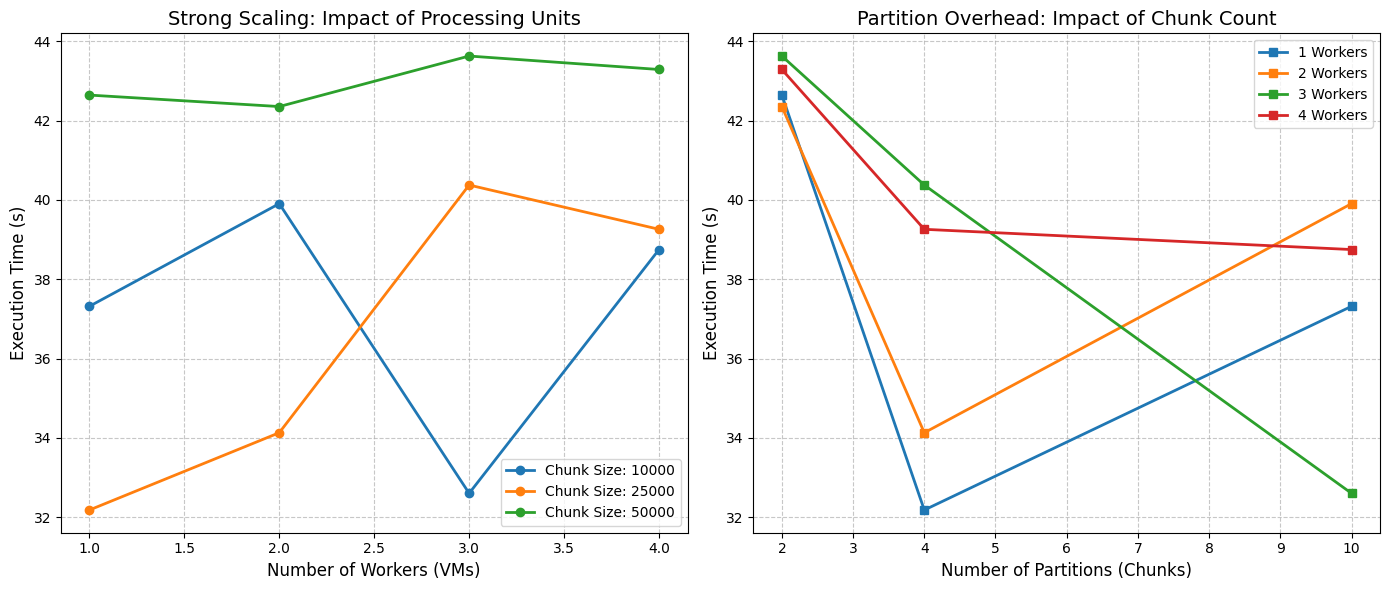

In [13]:
# Vizualization
df = pd.DataFrame(results)
print("\t=== RCV1 BENCHMARK RESULTS ===")
print(df)

# Plot 1: Impact of Processing Units (Strong Scaling)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
for chunk in chunk_sizes:
    subset = df[df["Chunk_Size"] == chunk]
    plt.plot(subset["Workers"], subset["Time"], marker='o', linewidth=2, label=f'Chunk Size: {chunk}')

plt.title("Strong Scaling: Impact of Processing Units", fontsize=14)
plt.xlabel("Number of Workers (VMs)", fontsize=12)
plt.ylabel("Execution Time (s)", fontsize=12)
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.7)

# Plot 2: Impact of Partitions
plt.subplot(1, 2, 2)
for worker in worker_counts:
    subset = df[df["Workers"] == worker]
    plt.plot(subset["Partitions"], subset["Time"], marker='s', linewidth=2, label=f'{worker} Workers')

plt.title("Partition Overhead: Impact of Chunk Count", fontsize=14)
plt.xlabel("Number of Partitions (Chunks)", fontsize=12)
plt.ylabel("Execution Time (s)", fontsize=12)
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

#### Experiment 2 - KDD Cup 99 (Dense)

In [14]:
# Parameters to Benchmark
worker_counts = [1, 2, 3, 4] 
chunk_sizes = [10000, 50000, 100000]
results = []

In [15]:
for n_workers in worker_counts:
    # Select subset of hosts (1 Scheduler + n_workers)
    current_hosts = [all_hosts[0]] + all_hosts[1:n_workers+1]
    
    print(f"\n--- Testing with {n_workers} Worker Nodes ---")
    
    # Start Cluster with specific number of nodes
    cluster = SSHCluster(
        current_hosts,
        connect_options={"known_hosts": None, "username": "ubuntu"},
        scheduler_options={"port": 8786, "dashboard_address": ":8787"},
        worker_options={"nthreads": 4, "memory_limit": "7GB"} # Standardize worker specs
    )
    client = Client(cluster)
    
    try:
        # Load Data Once per Cluster Start
        data = fetch_kddcup99(percent10=True, subset=None)
        X_raw = data.data
        X_num = X_raw[:, [0] + list(range(4, X_raw.shape[1]))].astype(np.float64)
        
        for chunk_size in chunk_sizes:
            print(f"   > Running Chunk Size: {chunk_size} ...", end=" ")
            
            # Re-partition data (Crucial step for Partitions Benchmark)
            X_dask = da.from_array(X_num, chunks=(chunk_size, X_num.shape[1]))
            X_scaled = StandardScaler().fit_transform(X_dask).persist()
            client.wait_for_workers(n_workers)
            
            # Run Algorithm
            model = KMeansParallel(k=23, max_iter=5) # Reduced iters for speed
            
            t0 = time.time()
            model.fit(X_scaled)
            t1 = time.time()
            
            elapsed = t1 - t0
            print(f"Done! ({elapsed:.2f}s)")
            
            # Save Result
            results.append({
                "Workers": n_workers,
                "Chunk_Size": chunk_size,
                "Partitions": X_dask.numblocks[0], # Actual number of partitions
                "Time": elapsed
            })
            
            # Clean memory for next chunk size
            del X_dask, X_scaled, model
            
    except Exception as e:
        print(f"Failed: {e}")
    finally:
        client.close()
        cluster.close()


--- Testing with 1 Worker Nodes ---


2026-02-07 20:02:48,713 - distributed.deploy.ssh - INFO - 2026-02-07 20:02:48,712 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-02-07 20:02:48,741 - distributed.deploy.ssh - INFO - 2026-02-07 20:02:48,741 - distributed.scheduler - INFO - State start
2026-02-07 20:02:48,744 - distributed.deploy.ssh - INFO - 2026-02-07 20:02:48,744 - distributed.scheduler - INFO -   Scheduler at:    tcp://10.67.22.10:8786
2026-02-07 20:02:49,599 - distributed.deploy.ssh - INFO - 2026-02-07 20:02:49,596 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.225:43123'
2026-02-07 20:02:49,896 - distributed.deploy.ssh - INFO - 2026-02-07 20:02:49,894 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/worker-5put_7l6', purging
2026-02-07 20:02:49,909 - distributed.deploy.ssh - INFO - 2026-02-07 20:02:49,906 - distributed.worker - INFO -  

   > Running Chunk Size: 10000 ... 

/home/ubuntu/.local/lib/python3.10/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 143.23 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/ubuntu/.local/lib/python3.10/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 143.23 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Done! (6.68s)
   > Running Chunk Size: 50000 ... 

...

Done! (4.24s)
   > Running Chunk Size: 50000 ... 

/home/ubuntu/.local/lib/python3.10/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 143.23 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/ubuntu/.local/lib/python3.10/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 143.23 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Done! (2.04s)
   > Running Chunk Size: 100000 ... 

/home/ubuntu/.local/lib/python3.10/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 143.23 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/ubuntu/.local/lib/python3.10/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 143.23 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Done! (2.80s)


	=== BENCHMARK RESULTS ===
    Workers  Chunk_Size  Partitions      Time
0         1       10000          50  6.675133
1         1       50000          10  3.059629
2         1      100000           5  2.983932
3         2       10000          50  5.500697
4         2       50000          10  3.020168
5         2      100000           5  3.037993
6         3       10000          50  4.921666
7         3       50000          10  2.212120
8         3      100000           5  3.305548
9         4       10000          50  4.236290
10        4       50000          10  2.043982
11        4      100000           5  2.795976


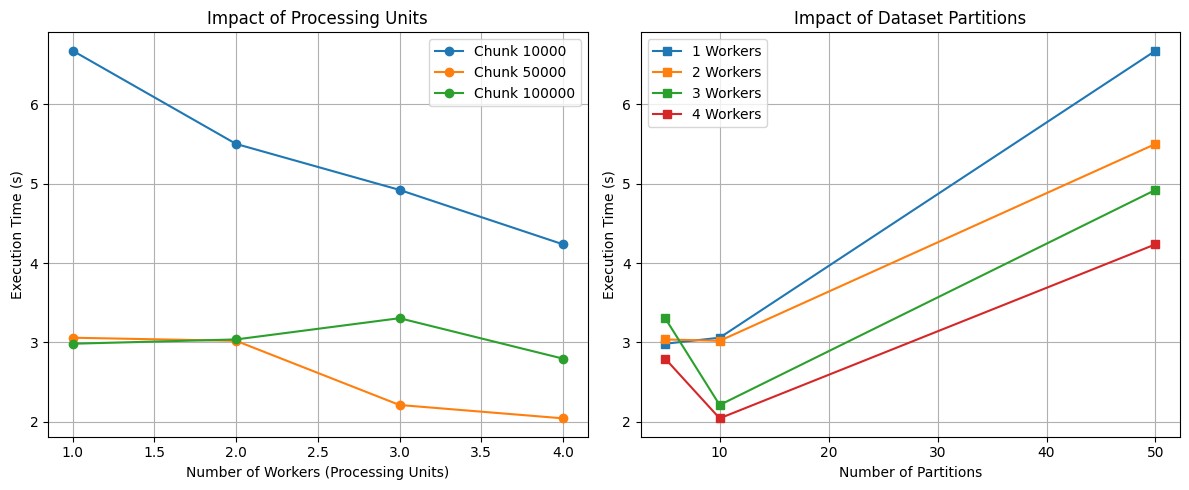

In [16]:
# Vizualization
df = pd.DataFrame(results)
print("\t=== BENCHMARK RESULTS ===")
print(df)

# Plot 1: Impact of Processing Units (Workers)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for chunk in chunk_sizes:
    subset = df[df["Chunk_Size"] == chunk]
    plt.plot(subset["Workers"], subset["Time"], marker='o', label=f'Chunk {chunk}')
plt.xlabel("Number of Workers (Processing Units)")
plt.ylabel("Execution Time (s)")
plt.title("Impact of Processing Units")
plt.legend()
plt.grid(True)

# Plot 2: Impact of partitions (Chunk Size)
plt.subplot(1, 2, 2)
for worker in worker_counts:
    subset = df[df["Workers"] == worker]
    plt.plot(subset["Partitions"], subset["Time"], marker='s', label=f'{worker} Workers')
plt.xlabel("Number of Partitions")
plt.ylabel("Execution Time (s)")
plt.title("Impact of Dataset Partitions")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()